# Exercise 4. 네트워크 공격 이벤트 군집화 — 완전 실습
UNSW-NB15로 K-Means, Agglomerative, DBSCAN, Gaussian Mixture를 비교합니다. 실제 `attack_cat`, `label`은 학습하지 않고 사후 분석에만 사용합니다.

In [1]:
import warnings, os, glob, numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
from IPython.display import display
RANDOM_STATE=42
np.random.seed(RANDOM_STATE)
pd.set_option("display.max_columns",100)
print("환경 준비 완료")

환경 준비 완료


In [2]:
EXPECTED_KEYWORD="unsw_nb15_sample"
paths=(glob.glob("/content/*.csv")+glob.glob("/content/drive/MyDrive/**/*.csv",recursive=True)
       +glob.glob("./*.csv")+glob.glob("/mnt/data/*.csv"))
matched=[p for p in paths if EXPECTED_KEYWORD.lower() in os.path.basename(p).lower()]
if not matched:
    from google.colab import files
    print("CSV 파일을 업로드하세요.")
    uploaded=files.upload()
    matched=list(uploaded.keys())
file_path=matched[0]
df=pd.read_csv(file_path)
print("파일:",file_path,"크기:",df.shape)
display(df.head())

CSV 파일을 업로드하세요.


Saving Exercise4. unsw_nb15_sample.csv to Exercise4. unsw_nb15_sample.csv
파일: Exercise4. unsw_nb15_sample.csv 크기: (3000, 45)


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,dload,sloss,dloss,sinpkt,dinpkt,sjit,djit,swin,stcpb,dtcpb,dwin,tcprtt,synack,ackdat,smean,dmean,trans_depth,response_body_len,ct_srv_src,ct_state_ttl,ct_dst_ltm,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,136319,0.000009,udp,dns,INT,2,0,114,0,111111.107200,254,0,5.066666e+07,0.000000,0,0,0.009000,0.000000,0.000000,0.000000,0,0,0,0,0.000000,0.000000,0.000000,57,0,0,0,26,2,16,16,16,26,0,0,0,16,26,0,Generic,1
1,57368,0.219511,tcp,-,FIN,10,8,472,564,77.444865,254,252,1.548897e+04,18003.654300,2,2,24.390111,27.390285,1372.203859,49.259012,255,3946740497,2358327248,255,0.030817,0.016798,0.014019,47,71,0,0,1,1,1,1,1,1,0,0,0,1,1,0,Backdoor,1
2,90544,0.000009,unas,-,INT,2,0,200,0,111111.107200,254,0,8.888889e+07,0.000000,0,0,0.009000,0.000000,0.000000,0.000000,0,0,0,0,0.000000,0.000000,0.000000,100,0,0,0,10,2,3,3,3,11,0,0,0,3,10,0,Exploits,1
3,51025,1.093025,tcp,-,FIN,10,8,2516,354,15.553167,254,252,1.657785e+04,2268.932617,2,1,115.407000,143.608719,7746.846685,195.241047,255,1429360674,4002771407,255,0.133766,0.087756,0.046010,252,44,0,0,3,1,2,1,1,2,0,0,0,2,3,0,Fuzzers,1
4,89739,2.034724,tcp,smtp,FIN,52,24,48180,1884,36.860036,62,252,1.857903e+05,7100.717285,23,8,39.896548,85.120563,3270.247065,116.130797,255,2383018343,1552474891,255,0.135775,0.076369,0.059406,927,79,0,0,1,1,1,1,1,1,0,0,0,1,1,0,Exploits,1


## 1. 데이터 이해

In [3]:
print(df.info()); print("중복:",df.duplicated().sum())
display(df.isnull().sum().sort_values(ascending=False).head(10).to_frame("결측치"))
display(df["attack_cat"].value_counts().to_frame("개수"))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 45 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 3000 non-null   int64  
 1   dur                3000 non-null   float64
 2   proto              3000 non-null   object 
 3   service            3000 non-null   object 
 4   state              3000 non-null   object 
 5   spkts              3000 non-null   int64  
 6   dpkts              3000 non-null   int64  
 7   sbytes             3000 non-null   int64  
 8   dbytes             3000 non-null   int64  
 9   rate               3000 non-null   float64
 10  sttl               3000 non-null   int64  
 11  dttl               3000 non-null   int64  
 12  sload              3000 non-null   float64
 13  dload              3000 non-null   float64
 14  sloss              3000 non-null   int64  
 15  dloss              3000 non-null   int64  
 16  sinpkt             3000 

,결측치
id,0
dur,0
proto,0
service,0
state,0
spkts,0
dpkts,0
sbytes,0
dbytes,0
rate,0


,개수
attack_cat,
Generic,983
Exploits,877
Fuzzers,490
DoS,273
Reconnaissance,256
Backdoor,47
Analysis,42
Shellcode,28
Worms,4


## 2. 전처리와 PCA
식별자와 정답을 제외하고 One-Hot Encoding·표준화·PCA를 적용합니다.

In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder,StandardScaler,LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
data=df.drop_duplicates().reset_index(drop=True); actual=data["attack_cat"].astype(str)
X=data.drop(columns=["id","attack_cat","label"])

num=X.select_dtypes(include=np.number).columns; cat=X.select_dtypes(exclude=np.number).columns

prep=ColumnTransformer([("num",Pipeline([("imp",SimpleImputer(strategy="median")),("sc",StandardScaler())]),num),
("cat",Pipeline([("imp",SimpleImputer(strategy="most_frequent")),("oh",OneHotEncoder(handle_unknown="ignore",sparse_output=False))]),cat)])

Xp=prep.fit_transform(X); pca=PCA(n_components=.95,random_state=RANDOM_STATE); Xr=pca.fit_transform(Xp)
print(X.shape,Xp.shape,Xr.shape,pca.explained_variance_ratio_.sum())

(3000, 42) (3000, 174) (3000, 18) 0.9558213780618919


## 3. K 탐색: Elbow와 Silhouette

,K,Inertia,Silhouette
0,2,81172.0194,0.4530
1,3,69003.1929,0.4169
2,4,58817.8732,0.4210
3,5,51429.8780,0.4260
4,6,45591.4314,0.4343
5,7,41009.9306,0.4468
6,8,35676.9558,0.4643
7,9,32955.4343,0.4473
8,10,30835.0793,0.4395


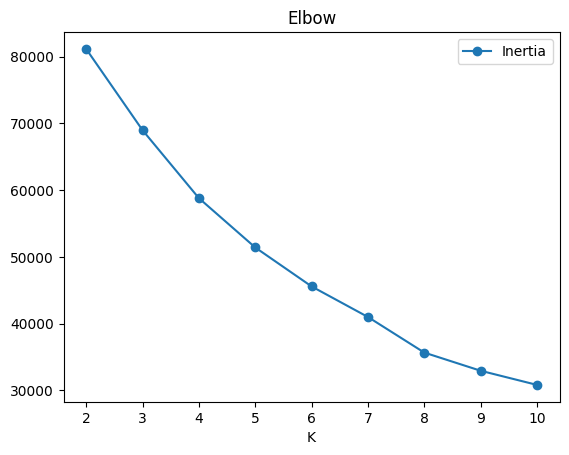

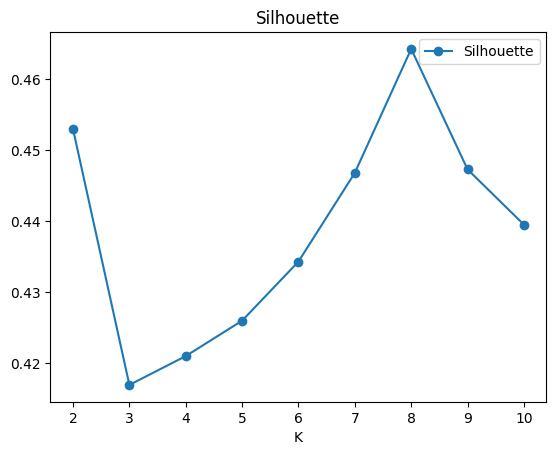

최적 K: 8


In [5]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
rows=[]
for k in range(2,11):
 m=KMeans(n_clusters=k,n_init=10,random_state=RANDOM_STATE); l=m.fit_predict(Xr)
 rows.append([k,m.inertia_,silhouette_score(Xr,l)])
ks=pd.DataFrame(rows,columns=["K","Inertia","Silhouette"]); display(ks.round(4))
ks.plot(x="K",y="Inertia",marker="o",title="Elbow"); plt.show()
ks.plot(x="K",y="Silhouette",marker="o",title="Silhouette"); plt.show()
best_k=int(ks.loc[ks["Silhouette"].idxmax(),"K"]); print("최적 K:",best_k)

## 4. 여러 군집화 모델

In [6]:
from sklearn.cluster import AgglomerativeClustering,DBSCAN
from sklearn.mixture import GaussianMixture
mods={"K-Means":KMeans(n_clusters=best_k,n_init=10,random_state=RANDOM_STATE),
"Agglomerative":AgglomerativeClustering(n_clusters=best_k),
"DBSCAN":DBSCAN(eps=1.5,min_samples=10),
"Gaussian Mixture":GaussianMixture(n_components=best_k,random_state=RANDOM_STATE)}
labels={}
for n,m in mods.items():
 labels[n]=(m.fit(Xr).predict(Xr) if n=="Gaussian Mixture" else m.fit_predict(Xr))
 print(n,np.unique(labels[n],return_counts=True))

K-Means (array([0, 1, 2, 3, 4, 5, 6, 7], dtype=int32), array([  35,  910,  862, 1046,    2,    1,    5,  139]))
Agglomerative (array([0, 1, 2, 3, 4, 5, 6, 7]), array([991, 920, 965,  83,   1,  35,   4,   1]))
DBSCAN (array([-1,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10]), array([ 468, 1746,  439,   25,  120,   18,   66,   41,   18,   39,   10,
         10]))
Gaussian Mixture (array([0, 1, 2, 3, 4, 5, 6, 7]), array([789, 986, 245, 439,   2,   1, 529,   9]))


## 5. 내부·외부 평가지표
Silhouette↑, Davies-Bouldin↓, Calinski-Harabasz↑가 일반적으로 좋습니다. ARI/NMI는 실제 공격 유형과 군집 구조의 유사성을 사후 확인합니다.

In [7]:
from sklearn.metrics import *
ae=LabelEncoder().fit_transform(actual); rows=[]
for n,l in labels.items():
 mask=l!=-1; u=np.unique(l[mask])
 if len(u)>=2:
  sil=silhouette_score(Xr[mask],l[mask]); db=davies_bouldin_score(Xr[mask],l[mask]); ch=calinski_harabasz_score(Xr[mask],l[mask])
 else: sil=db=ch=np.nan
 rows.append([n,len(u),(l==-1).mean(),sil,db,ch,adjusted_rand_score(ae,l),normalized_mutual_info_score(ae,l)])
result=pd.DataFrame(rows,columns=["Model","Clusters","Noise_Ratio","Silhouette","Davies_Bouldin","Calinski_Harabasz","ARI","NMI"]).sort_values("Silhouette",ascending=False)
display(result.round(4))

,Model,Clusters,Noise_Ratio,Silhouette,Davies_Bouldin,Calinski_Harabasz,ARI,NMI
0,K-Means,8,0.000,0.4643,0.7224,940.5374,0.3768,0.4013
1,Agglomerative,8,0.000,0.4440,0.6185,830.5638,0.3932,0.3879
3,Gaussian Mixture,8,0.000,0.2862,1.5042,696.0890,0.2685,0.4097
2,DBSCAN,11,0.156,0.1585,0.8249,436.3505,0.2063,0.2255


## 6. 군집별 공격 유형·정상/공격 분포

In [8]:
best=result.dropna(subset=["Silhouette"]).iloc[0]["Model"]; bl=labels[best]
out=data.copy(); out["cluster"]=bl
display(out["cluster"].value_counts().sort_index().to_frame("개수"))
display(pd.crosstab(out["cluster"],out["attack_cat"]))
display(pd.crosstab(out["cluster"],out["attack_cat"],normalize="index").round(3))
display(pd.crosstab(out["cluster"],out["label"],margins=True))

,개수
cluster,
0,35
1,910
2,862
3,1046
4,2
5,1
6,5
7,139


attack_cat,Analysis,Backdoor,DoS,Exploits,Fuzzers,Generic,Reconnaissance,Shellcode,Worms
cluster,,,,,,,,,
0,0,0,0,31,4,0,0,0,0
1,0,0,0,0,10,900,0,0,0
2,12,7,43,334,310,6,133,16,1
3,27,40,221,385,163,73,123,12,2
4,0,0,0,2,0,0,0,0,0
5,0,0,1,0,0,0,0,0,0
6,1,0,0,1,3,0,0,0,0
7,2,0,8,124,0,4,0,0,1


attack_cat,Analysis,Backdoor,DoS,Exploits,Fuzzers,Generic,Reconnaissance,Shellcode,Worms
cluster,,,,,,,,,
0,0.000,0.000,0.000,0.886,0.114,0.000,0.000,0.000,0.000
1,0.000,0.000,0.000,0.000,0.011,0.989,0.000,0.000,0.000
2,0.014,0.008,0.050,0.387,0.360,0.007,0.154,0.019,0.001
3,0.026,0.038,0.211,0.368,0.156,0.070,0.118,0.011,0.002
4,0.000,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000
5,0.000,0.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000
6,0.200,0.000,0.000,0.200,0.600,0.000,0.000,0.000,0.000
7,0.014,0.000,0.058,0.892,0.000,0.029,0.000,0.000,0.007


label,1,All
cluster,,
0,35,35
1,910,910
2,862,862
3,1046,1046
4,2,2
5,1,1
6,5,5
7,139,139
All,3000,3000


## 7. PCA 2차원 시각화 및 군집 프로파일

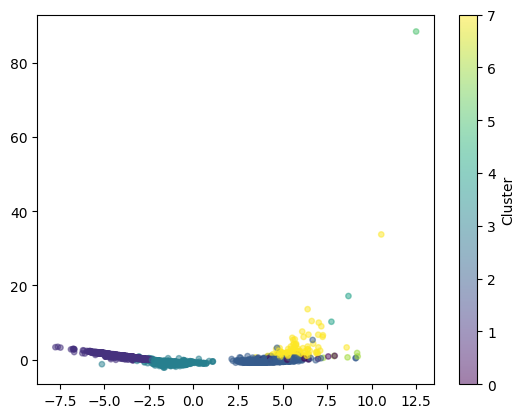

,dur,spkts,dpkts,sbytes,dbytes,rate,sload,dload
cluster,,,,,,,,
0,3.10,21.94,20.74,1164.80,1514.11,19.31,4.128390e+03,5265.28
1,0.00,2.00,0.00,120.96,0.00,211169.96,1.028937e+08,0.00
2,1.68,27.12,11.86,21730.69,956.25,32.39,6.631978e+04,7976.83
3,2.95,6.17,0.11,1575.30,14.39,185421.19,1.761642e+08,310.20
4,53.57,5633.00,878.00,7516020.50,38079.00,127.28,1.175966e+06,5916.71
5,59.99,1044.00,6994.00,45360.00,9347681.00,133.98,6.043760e+03,1246486.38
6,12.78,11.60,8.00,2360.40,542.40,15.38,5.004590e+03,4037.75
7,2.28,26.56,101.15,1653.24,123425.09,63.17,1.184348e+04,367471.02


In [9]:
X2=PCA(n_components=2,random_state=RANDOM_STATE).fit_transform(Xp)
plt.scatter(X2[:,0],X2[:,1],c=bl,s=15,alpha=.5); plt.colorbar(label="Cluster"); plt.show()
features=[c for c in ["dur","spkts","dpkts","sbytes","dbytes","rate","sload","dload"] if c in out]
display(out.groupby("cluster")[features].mean().round(2))

## 8. K-Means 중심점 해석

In [10]:
km=mods["K-Means"]; centers=pca.inverse_transform(km.cluster_centers_)
cdf=pd.DataFrame(centers,columns=prep.get_feature_names_out())
for i in range(len(cdf)):
 print(f"군집 {i}의 큰 특징"); display(cdf.iloc[i].sort_values(ascending=False).head(10).to_frame("center"))

군집 0의 큰 특징


,center
num__is_ftp_login,8.379515
num__ct_ftp_cmd,8.379515
num__djit,2.898982
num__dwin,1.379901
num__swin,1.379901
num__dttl,1.377636
num__ackdat,1.344163
num__tcprtt,1.210830
num__dtcpb,1.181618
num__synack,1.014308


군집 1의 큰 특징


,center
num__ct_srv_dst,1.385890
num__ct_srv_src,1.382343
num__ct_dst_src_ltm,1.374023
num__ct_src_dport_ltm,1.321491
num__ct_dst_sport_ltm,1.313415
num__ct_dst_ltm,1.304475
num__ct_src_ltm,1.184588
cat__state_INT,0.999446
cat__proto_udp,0.952536
cat__service_dns,0.939097


군집 2의 큰 특징


...

,center
num__response_body_len,50.270424
num__dbytes,50.029265
num__dloss,49.985620
num__dpkts,49.157567
num__dload,10.984777
num__dur,7.903007
num__spkts,6.343104
num__dmean,6.083927
num__trans_depth,3.032808
num__ct_flw_http_mthd,2.092149


군집 6의 큰 특징


,center
num__sjit,21.331024
num__dinpkt,21.267944
num__djit,15.568184
num__sinpkt,7.297494
num__ct_flw_http_mthd,2.028095
num__dur,1.943294
num__tcprtt,1.688837
num__synack,1.658453
num__ackdat,1.619100
num__dttl,1.365191


군집 7의 큰 특징


,center
num__dmean,3.781133
num__dload,3.402756
num__trans_depth,1.665934
num__dttl,1.374376
num__swin,1.364941
num__dwin,1.364941
num__djit,1.345568
num__stcpb,1.087813
num__dtcpb,1.060102
num__ackdat,1.038661


In [11]:
output_path="/content/exercise4_results.csv" if os.path.isdir("/content") else "./exercise4_results.csv"
out.to_csv(output_path,index=False,encoding="utf-8-sig"); print("저장 완료")

저장 완료
